# Pair selection: correlation and cointegration

Select potential stock pairs using only days 0–300:
1. correlation screen 
2. log-price cointegration 
3. FDR and half-life filters 
4. rolling stability
5. ranked research shortlist. 

This notebook stops at pair selection; it does not define a trading strategy.

In [62]:
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests
from statsmodels.tsa.stattools import coint

DISCOVERY_DAYS = 300
CORRELATION_FLOOR = 0.15
FDR_Q_THRESHOLD = 0.10
EXPLORATORY_P_THRESHOLD = 0.01
MIN_HALF_LIFE_DAYS = 1
MAX_HALF_LIFE_DAYS = 90
MIN_ROLLING_COINT_PASS_PCT = 60
MAX_BETA_RELATIVE_RANGE = 1.25
ROLLING_WINDOW = 250
ROLLING_STEP = 5

repo_root = Path.cwd()
if not (repo_root / 'backtester').exists():
    repo_root = repo_root.parent

prices_full = pd.read_csv(repo_root / 'backtester' / 'data' / '2026' / 'prices.txt', sep=r'\s+')
prices = prices_full.iloc[:DISCOVERY_DAYS].copy()
stock_tickers = prices.columns.drop('ALGO')
returns = prices.pct_change(fill_method=None)
stock_returns = returns[stock_tickers]
log_prices = np.log(prices[stock_tickers])

## 1. Correlation screen

Screen non-ALGO stock pairs by absolute daily-return correlation. The 0.15 floor is deliberately modest: it removes weakly related pairs without excluding potentially cointegrated pairs with only moderate same-day correlation.

In [63]:
return_correlation = stock_returns.corr()
upper_triangle = return_correlation.where(np.triu(np.ones(return_correlation.shape), k=1).astype(bool))
correlation_pairs = (
    upper_triangle.stack()
    .rename('return_correlation')
    .rename_axis(['ticker_a', 'ticker_b'])
    .reset_index()
    .assign(abs_return_correlation=lambda frame: frame['return_correlation'].abs())
    .sort_values('abs_return_correlation', ascending=False)
)
correlation_screen = correlation_pairs.query('abs_return_correlation >= @CORRELATION_FLOOR').copy()

print(f'{len(correlation_screen)} of {len(correlation_pairs)} stock pairs pass |correlation| ≥ {CORRELATION_FLOOR:.2f}.')
display(correlation_pairs.head(20).style.format({
    'return_correlation': '{:+.3f}',
    'abs_return_correlation': '{:.3f}',
}))

766 of 1225 stock pairs pass |correlation| ≥ 0.15.


,ticker_a,ticker_b,return_correlation,abs_return_correlation
1124,FWWG,BLBT,+0.476,0.476
1126,FWWG,ITPA,+0.467,0.467
1080,MTNS,BENI,+0.459,0.459
586,CUBO,BENI,+0.446,0.446
1192,BENI,ILVX,+0.443,0.443
135,SRNA,BENI,+0.436,0.436
1046,ACIX,ITPA,+0.429,0.429
884,RRES,NAYO,+0.428,0.428
139,SRNA,ILVX,+0.415,0.415
577,CUBO,MTNS,+0.413,0.413


**Notes / interpretation**

- This is only a screening table. High return correlation does not imply a stable price spread or a tradable mean-reversion relationship.
- The next test asks the more relevant question: whether a hedge-adjusted log-price spread is mean-reverting.

## 2. Cointegration on log prices

Run Engle–Granger tests only on the correlation-screened pairs. FDR-adjusted q-values control for the multiple tests remaining after screening.

In [64]:
rows = []
for row in correlation_screen.itertuples():
    ticker_a, ticker_b = row.ticker_a, row.ticker_b
    log_a, log_b = log_prices[ticker_a], log_prices[ticker_b]
    coint_statistic, p_value, _ = coint(log_a, log_b)
    hedge_beta, intercept = np.polyfit(log_b, log_a, 1)
    spread = log_a - (intercept + hedge_beta * log_b)
    delta_spread = spread.diff().dropna()
    lagged_spread = spread.shift(1).loc[delta_spread.index]
    mean_reversion_speed = np.polyfit(lagged_spread, delta_spread, 1)[0]
    half_life_days = -np.log(2) / mean_reversion_speed if mean_reversion_speed < 0 else np.inf
    rows.append({
        'ticker_a': ticker_a, 'ticker_b': ticker_b,
        'return_correlation': row.return_correlation,
        'coint_statistic': coint_statistic, 'p_value': p_value,
        'hedge_beta': hedge_beta, 'half_life_days': half_life_days,
    })

cointegration_results = pd.DataFrame(rows)
cointegration_results['fdr_q_value'] = multipletests(cointegration_results['p_value'], method='fdr_bh')[1]
cointegration_results = cointegration_results.sort_values(['fdr_q_value', 'p_value']).reset_index(drop=True)
display(cointegration_results.head(20).style.format({
    'return_correlation': '{:+.3f}', 'coint_statistic': '{:.3f}',
    'p_value': '{:.4g}', 'fdr_q_value': '{:.4g}',
    'hedge_beta': '{:.3f}', 'half_life_days': '{:.1f}',
}))

,ticker_a,ticker_b,return_correlation,coint_statistic,p_value,hedge_beta,half_life_days,fdr_q_value
0,GARI,EELT,+0.222,-5.227,6.159e-05,-0.657,5.3,0.04718
1,AENO,NWIG,+0.159,-4.622,0.0007669,0.800,3.6,0.2937
2,SMAH,ILVX,+0.305,-4.396,0.001804,1.085,4.6,0.3061
3,CTGI,EELT,+0.251,-4.386,0.001871,0.888,5.8,0.3061
4,EORC,NGTE,+0.218,-4.368,0.001998,0.983,4.6,0.3061
5,CTGI,GARI,+0.196,-4.201,0.003629,-0.941,7.5,0.4634
6,MHRM,EAFC,+0.355,-4.089,0.005345,0.585,5.1,0.5535
7,MTNS,BENI,+0.459,-4.065,0.00578,0.986,6.6,0.5535
8,SMAH,EORC,+0.189,-3.975,0.007791,1.044,6.7,0.6624
9,HUXZ,ACAC,+0.165,-3.943,0.008647,0.864,6.9,0.6624


## 3. Evidence tiers, half-life, and rolling stability

Use two evidence tiers. **FDR-confirmed** pairs have q < 0.10. **Exploratory candidates** have raw Engle–Granger p < 0.01 but do not survive FDR correction. Both tiers must have a positive 1–90 day half-life, cointegration in at least 60% of rolling windows, and a hedge-beta relative range no larger than 1.25. The exploratory tier is for tuning research only—not a claim of statistical confirmation.

**Why only one FDR-confirmed pair?** The correlation screen leaves 766 tests. Benjamini–Hochberg correction is therefore severe: for example, a raw p-value around 0.0008 can become a q-value around 0.29. This is expected; it does not mean the other low-p pairs are automatically bad.

**Rolling-window caveat:** 300 discovery days with a 250-day window produces only 11 heavily overlapping windows. Treat rolling results as a useful stability check, not independent confirmation.

In [65]:
def rolling_pair_metrics(ticker_a, ticker_b):
    hedge_betas, p_values = [], []
    for end in range(ROLLING_WINDOW, len(prices) + 1, ROLLING_STEP):
        log_a = log_prices[ticker_a].iloc[end - ROLLING_WINDOW:end]
        log_b = log_prices[ticker_b].iloc[end - ROLLING_WINDOW:end]
        hedge_betas.append(np.polyfit(log_b, log_a, 1)[0])
        p_values.append(coint(log_a, log_b)[1])
    beta_median = float(np.median(hedge_betas))
    beta_relative_range = float((max(hedge_betas) - min(hedge_betas)) / abs(beta_median))
    return {
        'rolling_coint_pass_pct': float(np.mean(np.asarray(p_values) < 0.05) * 100),
        'rolling_median_p_value': float(np.median(p_values)),
        'rolling_beta_min': float(min(hedge_betas)),
        'rolling_beta_max': float(max(hedge_betas)),
        'beta_relative_range': beta_relative_range,
    }

rolling_metrics = [
    rolling_pair_metrics(row.ticker_a, row.ticker_b)
    for row in cointegration_results.itertuples()
]
pair_evidence = pd.concat([cointegration_results, pd.DataFrame(rolling_metrics)], axis=1)
stable_rolling_evidence = (
    pair_evidence['half_life_days'].between(MIN_HALF_LIFE_DAYS, MAX_HALF_LIFE_DAYS)
    & (pair_evidence['rolling_coint_pass_pct'] >= MIN_ROLLING_COINT_PASS_PCT)
    & (pair_evidence['beta_relative_range'] <= MAX_BETA_RELATIVE_RANGE)
)
pair_evidence['selection_tier'] = np.select(
    [
        stable_rolling_evidence & (pair_evidence['fdr_q_value'] < FDR_Q_THRESHOLD),
        stable_rolling_evidence & (pair_evidence['p_value'] < EXPLORATORY_P_THRESHOLD),
    ],
    ['FDR-confirmed', 'Exploratory: raw p < 0.01'],
    default='Does not pass',
)
pair_evidence['passes_selection'] = pair_evidence['selection_tier'].ne('Does not pass')

display(pair_evidence.sort_values(['passes_selection', 'fdr_q_value'], ascending=[False, True]).head(20).style.format({
    'return_correlation': '{:+.3f}', 'p_value': '{:.4g}', 'fdr_q_value': '{:.4g}',
    'half_life_days': '{:.1f}', 'rolling_coint_pass_pct': '{:.0f}%',
    'rolling_median_p_value': '{:.3f}', 'rolling_beta_min': '{:.2f}',
    'rolling_beta_max': '{:.2f}', 'beta_relative_range': '{:.2f}',
}))

,ticker_a,ticker_b,return_correlation,coint_statistic,p_value,hedge_beta,half_life_days,fdr_q_value,rolling_coint_pass_pct,rolling_median_p_value,rolling_beta_min,rolling_beta_max,beta_relative_range,passes_selection
0,GARI,EELT,+0.222,-5.227194,0.000062,-0.656759,5.3,0.04718,100%,0.000,-0.71,-0.61,0.15,True
1,AENO,NWIG,+0.159,-4.621855,0.000767,0.800396,3.6,0.2937,100%,0.001,0.70,0.81,0.14,False
2,SMAH,ILVX,+0.305,-4.396298,0.001804,1.085285,4.6,0.3061,100%,0.008,1.09,1.12,0.03,False
3,CTGI,EELT,+0.251,-4.386426,0.001871,0.887944,5.8,0.3061,100%,0.003,0.79,0.97,0.20,False
4,EORC,NGTE,+0.218,-4.368478,0.001998,0.982735,4.6,0.3061,100%,0.003,0.89,0.98,0.10,False
5,CTGI,GARI,+0.196,-4.201445,0.003629,-0.941458,7.5,0.4634,100%,0.011,-1.00,-0.75,0.28,False
6,MHRM,EAFC,+0.355,-4.088681,0.005345,0.584962,5.1,0.5535,91%,0.012,0.52,0.64,0.20,False
7,MTNS,BENI,+0.459,-4.065419,0.005780,0.986255,6.6,0.5535,91%,0.020,0.96,1.16,0.19,False
8,SMAH,EORC,+0.189,-3.975062,0.007791,1.043659,6.7,0.6624,100%,0.016,1.08,1.12,0.04,False
9,HUXZ,ACAC,+0.165,-3.942886,0.008647,0.864185,6.9,0.6624,91%,0.023,0.85,0.88,0.04,False


## 4. Rolling evidence for selected research pairs

Each figure shows the 250-day rolling hedge beta and Engle–Granger p-value for an FDR-confirmed or exploratory candidate pair.

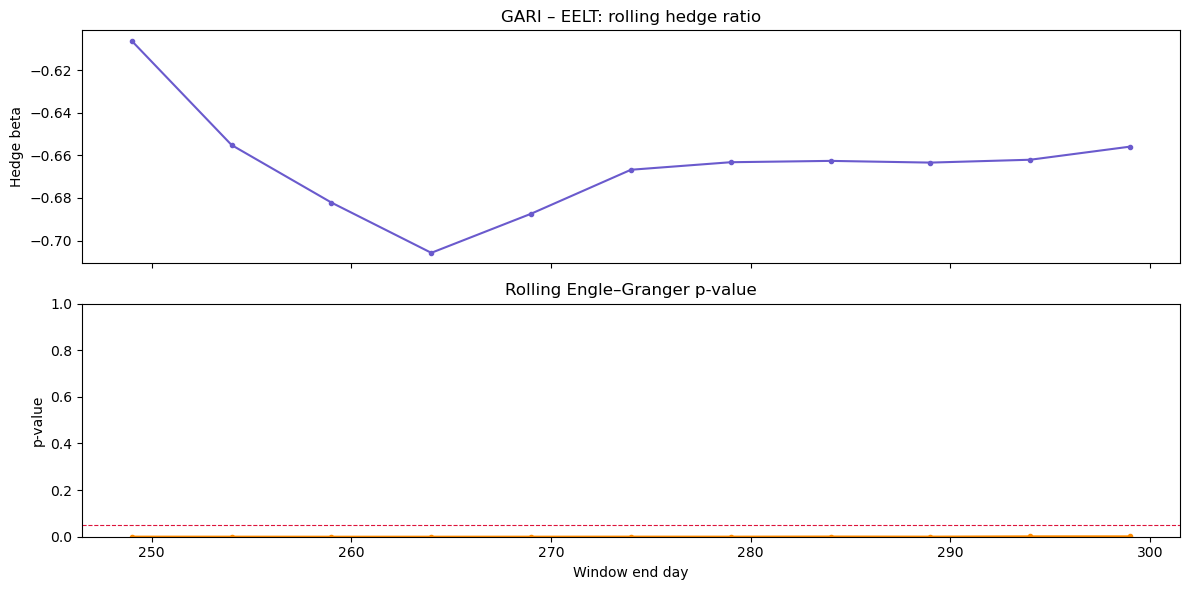

In [66]:
shortlisted_pairs = pair_evidence.query('passes_selection').copy()

for row in shortlisted_pairs.itertuples():
    ticker_a, ticker_b = row.ticker_a, row.ticker_b
    ends, hedge_betas, p_values = [], [], []
    for end in range(ROLLING_WINDOW, len(prices) + 1, ROLLING_STEP):
        log_a = log_prices[ticker_a].iloc[end - ROLLING_WINDOW:end]
        log_b = log_prices[ticker_b].iloc[end - ROLLING_WINDOW:end]
        ends.append(end - 1)
        hedge_betas.append(np.polyfit(log_b, log_a, 1)[0])
        p_values.append(coint(log_a, log_b)[1])
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    axes[0].plot(ends, hedge_betas, marker='o', markersize=3, color='slateblue')
    axes[0].set(title=f'{ticker_a} – {ticker_b}: rolling hedge ratio', ylabel='Hedge beta')
    axes[1].plot(ends, p_values, marker='o', markersize=3, color='darkorange')
    axes[1].axhline(0.05, color='crimson', linewidth=0.8, linestyle='--')
    axes[1].set(title='Rolling Engle–Granger p-value', xlabel='Window end day', ylabel='p-value', ylim=(0, 1))
    plt.tight_layout()
    plt.show()

## 5. Draft pair choices

Rank the selected research pairs by evidence tier, then lower raw p-value, higher rolling cointegration pass rate, and lower hedge-beta instability. These are research choices only—not approved strategies.

In [67]:
tier_order = pd.CategoricalDtype(['FDR-confirmed', 'Exploratory: raw p < 0.01'], ordered=True)
shortlisted_pairs['selection_tier'] = shortlisted_pairs['selection_tier'].astype(tier_order)
draft_pair_choices = shortlisted_pairs.sort_values(
    ['selection_tier', 'p_value', 'rolling_coint_pass_pct', 'beta_relative_range'],
    ascending=[True, True, False, True],
).reset_index(drop=True)
draft_pair_choices.index = draft_pair_choices.index + 1

display(draft_pair_choices[[
    'selection_tier', 'ticker_a', 'ticker_b', 'return_correlation', 'p_value', 'fdr_q_value',
    'half_life_days', 'rolling_coint_pass_pct',
    'rolling_beta_min', 'rolling_beta_max', 'beta_relative_range',
]].style.format({
    'return_correlation': '{:+.3f}', 'p_value': '{:.4g}', 'fdr_q_value': '{:.4g}',
    'half_life_days': '{:.1f}', 'rolling_coint_pass_pct': '{:.0f}%',
    'rolling_beta_min': '{:.2f}', 'rolling_beta_max': '{:.2f}',
    'beta_relative_range': '{:.2f}',
}))

,ticker_a,ticker_b,return_correlation,fdr_q_value,half_life_days,rolling_coint_pass_pct,rolling_beta_min,rolling_beta_max,beta_relative_range
1,GARI,EELT,+0.222,0.04718,5.3,100%,-0.71,-0.61,0.15


**Notes / interpretation**

- Treat FDR-confirmed pairs as the strongest statistical evidence. Exploratory pairs have strong raw and rolling evidence, but may include false positives after many tests; tune and validate them separately.
- Do not use the holdout period (days 501–750) to adjust this ranking.